In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import time
import warnings
warnings.filterwarnings('ignore')

# Load and prepare data
digits = load_digits()
X, y = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Digits dataset loaded. Training with Random Forest and AdaBoost...")
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")


Digits dataset loaded. Training with Random Forest and AdaBoost...
Training samples: 1437, Test samples: 360


In [3]:

# ========= PART A: RANDOM FOREST ====================
print("\n" + "="*50 + "\nPART A: RANDOM FOREST\n" + "="*50)

# Train Random Forest with tuning
rf_params = {'n_estimators': [50, 100, 200], 'max_depth': [10, 20, None]}
rf_grid = GridSearchCV(RandomForestClassifier(oob_score=True, random_state=42), rf_params, cv=3, n_jobs=-1)
rf_grid.fit(X_train, y_train)
rf = rf_grid.best_estimator_

# Calculate metrics
start_time = time.time()
rf.fit(X_train, y_train)
rf_train_time = time.time() - start_time

start_time = time.time()
y_pred_rf = rf.predict(X_test)
rf_pred_time = time.time() - start_time

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Best RF params: {rf_grid.best_params_}")
print(f"RF Accuracy: {rf_accuracy:.4f}, OOB Error: {1-rf.oob_score_:.4f}")
print(f"RF Train time: {rf_train_time:.3f}s, Predict time: {rf_pred_time:.3f}s")



PART A: RANDOM FOREST
Best RF params: {'max_depth': 10, 'n_estimators': 200}
RF Accuracy: 0.9722, OOB Error: 0.0278
RF Train time: 1.218s, Predict time: 0.028s


In [4]:
# ===========PART B: ADABOOST ====================
print("\n" + "="*50 + "\nPART B: ADABOOST\n" + "="*50)

# Create AdaBoost with DecisionTreeClassifier (max_depth=1 for stump)
base_dt = DecisionTreeClassifier(max_depth=1, random_state=42)

# Train AdaBoost with tuning - FIXED: Using estimator parameter instead of base_estimator
ada_params = {
    'n_estimators': [50, 100, 200], 
    'learning_rate': [0.1, 0.5, 1.0]
}

ada_grid = GridSearchCV(
    AdaBoostClassifier(estimator=base_dt, random_state=42), 
    ada_params, 
    cv=3, 
    n_jobs=-1
)
ada_grid.fit(X_train, y_train)
ada = ada_grid.best_estimator_

# Calculate metrics
start_time = time.time()
ada.fit(X_train, y_train)
ada_train_time = time.time() - start_time
start_time = time.time()
y_pred_ada = ada.predict(X_test)
ada_pred_time = time.time() - start_time

ada_accuracy = accuracy_score(y_test, y_pred_ada)

print(f"Best AdaBoost params: {ada_grid.best_params_}")
print(f"AdaBoost Accuracy: {ada_accuracy:.4f}")
print(f"AdaBoost Train time: {ada_train_time:.3f}s, Predict time: {ada_pred_time:.3f}s")



PART B: ADABOOST
Best AdaBoost params: {'learning_rate': 1.0, 'n_estimators': 200}
AdaBoost Accuracy: 0.8639
AdaBoost Train time: 1.235s, Predict time: 0.050s


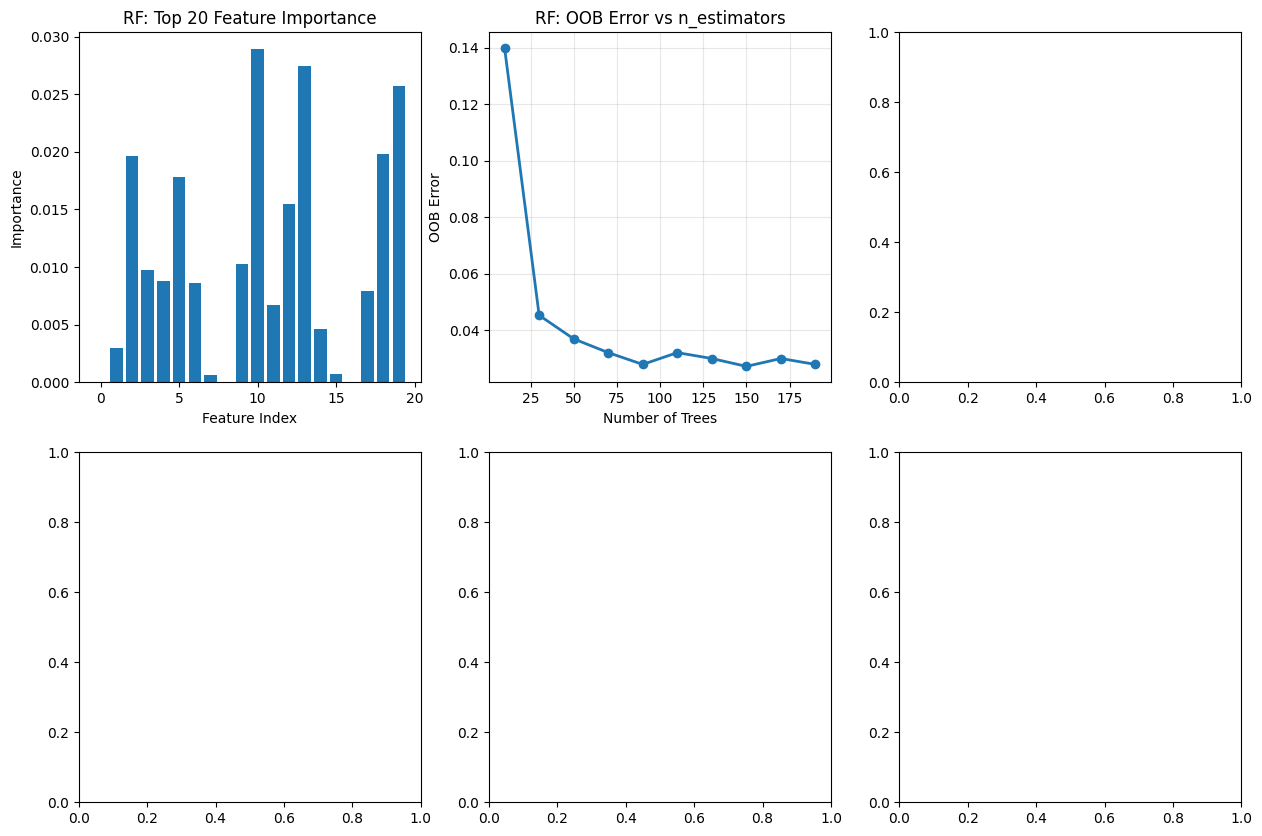

In [5]:
# ==================== VISUALIZATIONS ====================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Feature Importance
axes[0, 0].bar(range(20), rf.feature_importances_[:20])
axes[0, 0].set_title('RF: Top 20 Feature Importance')
axes[0, 0].set_xlabel('Feature Index')
axes[0, 0].set_ylabel('Importance')
# 2. OOB Error vs n_estimators
oob_errors = []
for n in range(10, 201, 20):
    rf_temp = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42, n_jobs=-1)
    rf_temp.fit(X_train, y_train)
    oob_errors.append(1 - rf_temp.oob_score_)
axes[0, 1].plot(range(10, 201, 20), oob_errors, 'o-', linewidth=2, markersize=6)
axes[0, 1].set_title('RF: OOB Error vs n_estimators')
axes[0, 1].set_xlabel('Number of Trees')
axes[0, 1].set_ylabel('OOB Error')
axes[0, 1].grid(True, alpha=0.3)


In [6]:
# 3. AdaBoost Error vs Iterations
test_errors = []
train_errors = []
ada_temp = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1), 
    n_estimators=200, 
    learning_rate=0.5, 
    random_state=42
)
ada_temp.fit(X_train, y_train)
for y_pred in ada_temp.staged_predict(X_test):
    test_errors.append(1 - accuracy_score(y_test, y_pred))
    
for y_pred in ada_temp.staged_predict(X_train):
    train_errors.append(1 - accuracy_score(y_train, y_pred))
axes[0, 2].plot(range(1, 201), test_errors, label='Test Error', linewidth=2)
axes[0, 2].plot(range(1, 201), train_errors, label='Train Error', linewidth=2, alpha=0.7)
axes[0, 2].set_title('AdaBoost: Error vs Iterations')
axes[0, 2].set_xlabel('Number of Estimators')
axes[0, 2].set_ylabel('Error Rate')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)
# 4. Performance Comparison
metrics = ['Accuracy', 'Train Time', 'Pred Time']
rf_vals = [rf_accuracy, rf_train_time * 100, rf_pred_time * 1000]  # Scaled for better visualization
ada_vals = [ada_accuracy, ada_train_time * 100, ada_pred_time * 1000]
x = np.arange(len(metrics))
width = 0.35
bars1 = axes[1, 0].bar(x - width/2, rf_vals, width, label='Random Forest', color='skyblue', alpha=0.8)
bars2 = axes[1, 0].bar(x + width/2, ada_vals, width, label='AdaBoost', color='lightgreen', alpha=0.8)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(metrics)
axes[1, 0].set_title('Performance Comparison')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')
# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.2f}', ha='center', va='bottom', fontsize=8)

In [7]:
# 5. RF Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
im1 = axes[1, 1].imshow(cm_rf, cmap='Blues', aspect='auto')
axes[1, 1].set_title('RF Confusion Matrix')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Actual')
plt.colorbar(im1, ax=axes[1, 1], fraction=0.046, pad=0.04)

# Add text to confusion matrix
for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        axes[1, 1].text(j, i, cm_rf[i, j], ha='center', va='center', 
                       color='white' if cm_rf[i, j] > cm_rf.max()/2 else 'black', fontsize=8)
# 6. AdaBoost Confusion Matrix
cm_ada = confusion_matrix(y_test, y_pred_ada)
im2 = axes[1, 2].imshow(cm_ada, cmap='Greens', aspect='auto')
axes[1, 2].set_title('AdaBoost Confusion Matrix')
axes[1, 2].set_xlabel('Predicted')
axes[1, 2].set_ylabel('Actual')
plt.colorbar(im2, ax=axes[1, 2], fraction=0.046, pad=0.04)
# Add text to confusion matrix
for i in range(cm_ada.shape[0]):
    for j in range(cm_ada.shape[1]):
        axes[1, 2].text(j, i, cm_ada[i, j], ha='center', va='center', 
                       color='white' if cm_ada[i, j] > cm_ada.max()/2 else 'black', fontsize=8)
plt.suptitle('Ensemble Methods Analysis on Digits Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
# ================COMPARISON TABLE ====================
print("\n" + "="*60 + "\nCOMPARISON TABLE\n" + "="*60)
print(f"{'Metric':<25} {'Random Forest':<20} {'AdaBoost':<20}")
print("-" * 60)
print(f"{'Accuracy':<25} {rf_accuracy:<20.4f} {ada_accuracy:<20.4f}")
print(f"{'Training Time (s)':<25} {rf_train_time:<20.3f} {ada_train_time:<20.3f}")
print(f"{'Prediction Time (ms)':<25} {rf_pred_time*1000:<20.2f} {ada_pred_time*1000:<20.2f}")
print(f"{'OOB/Test Error':<25} {1-rf.oob_score_:<20.4f} {1-ada_accuracy:<20.4f}")
print(f"{'Best n_estimators':<25} {rf.n_estimators:<20} {ada.n_estimators:<20}")
if hasattr(rf, 'max_depth'):
    print(f"{'Max Depth':<25} {rf.max_depth if rf.max_depth else 'None':<20} {ada.estimator.max_depth:<20}")
print("-" * 60)

<Figure size 640x480 with 0 Axes>


COMPARISON TABLE
Metric                    Random Forest        AdaBoost            
------------------------------------------------------------
Accuracy                  0.9722               0.8639              
Training Time (s)         1.218                1.235               
Prediction Time (ms)      27.75                49.53               
OOB/Test Error            0.0278               0.1361              
Best n_estimators         200                  200                 
Max Depth                 10                   1                   
------------------------------------------------------------


In [8]:
from sklearn.ensemble import GradientBoostingClassifier, StackingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from scipy.stats import randint, uniform

In [9]:
# ============= PART C: GRADIENT BOOSTING ====================
print("\n" + "="*50 + "\nPART C: GRADIENT BOOSTING\n" + "="*50)

# Train Gradient Boosting with tuning
gb_params = {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 5, 7]}
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_params, cv=3, n_jobs=-1)
gb_grid.fit(X_train, y_train)
gb = gb_grid.best_estimator_

# Calculate metrics
start_time = time.time()
gb.fit(X_train, y_train)
gb_train_time = time.time() - start_time

start_time = time.time()
y_pred_gb = gb.predict(X_test)
gb_pred_time = time.time() - start_time

gb_accuracy = accuracy_score(y_test, y_pred_gb)

print(f"Best GB params: {gb_grid.best_params_}")
print(f"GB Accuracy: {gb_accuracy:.4f}")
print(f"GB Train time: {gb_train_time:.3f}s, Predict time: {gb_pred_time:.3f}s")


PART C: GRADIENT BOOSTING
Best GB params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}
GB Accuracy: 0.9750
GB Train time: 13.131s, Predict time: 0.009s


In [10]:
# ============= PART D: STACKING ENSEMBLE ====================
print("\n" + "="*50 + "\nPART D: STACKING ENSEMBLE\n" + "="*50)

# Define base learners
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('ada', AdaBoostClassifier(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('svm', SVC(probability=True, random_state=42))
]

# Meta learner
meta_learner = LogisticRegression(random_state=42)

# Create stacking classifier
stacking = StackingClassifier(estimators=base_learners, final_estimator=meta_learner, cv=3)

# Train stacking
start_time = time.time()
stacking.fit(X_train, y_train)
stacking_train_time = time.time() - start_time

start_time = time.time()
y_pred_stacking = stacking.predict(X_test)
stacking_pred_time = time.time() - start_time

stacking_accuracy = accuracy_score(y_test, y_pred_stacking)

print(f"Stacking Accuracy: {stacking_accuracy:.4f}")
print(f"Stacking Train time: {stacking_train_time:.3f}s, Predict time: {stacking_pred_time:.3f}s")


PART D: STACKING ENSEMBLE
Stacking Accuracy: 0.9861
Stacking Train time: 30.823s, Predict time: 0.042s


In [11]:
# ============= PART E: HYPERPARAMETER TUNING WITH RANDOMIZEDSEARCHCV ====================
print("\n" + "="*50 + "\nPART E: HYPERPARAMETER TUNING (RandomizedSearchCV)\n" + "="*50)

# Define parameter distributions for Random Forest
rf_param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': [None] + list(range(5, 31, 5)),
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 5),
    'bootstrap': [True, False]
}

# Perform RandomizedSearchCV
rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, oob_score=True),
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=3,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)
rf_tuned = rf_random.best_estimator_

# Calculate metrics for tuned RF
start_time = time.time()
rf_tuned.fit(X_train, y_train)
rf_tuned_train_time = time.time() - start_time

start_time = time.time()
y_pred_rf_tuned = rf_tuned.predict(X_test)
rf_tuned_pred_time = time.time() - start_time

rf_tuned_accuracy = accuracy_score(y_test, y_pred_rf_tuned)

print(f"Best RF params (RandomizedSearch): {rf_random.best_params_}")
print(f"Tuned RF Accuracy: {rf_tuned_accuracy:.4f}, OOB Error: {1-rf_tuned.oob_score_:.4f}")
print(f"Tuned RF Train time: {rf_tuned_train_time:.3f}s, Predict time: {rf_tuned_pred_time:.3f}s")


PART E: HYPERPARAMETER TUNING (RandomizedSearchCV)
Best RF params (RandomizedSearch): {'bootstrap': True, 'max_depth': 30, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 264}
Tuned RF Accuracy: 0.9750, OOB Error: 0.0285
Tuned RF Train time: 0.893s, Predict time: 0.013s


In [12]:
# ============= PART F: EFFECT OF BOOTSTRAP SAMPLING IN RANDOM FOREST ====================
print("\n" + "="*50 + "\nPART F: BOOTSTRAP SAMPLING ANALYSIS\n" + "="*50)

# Compare RF with and without bootstrap
rf_bootstrap = RandomForestClassifier(n_estimators=100, bootstrap=True, oob_score=True, random_state=42)
rf_no_bootstrap = RandomForestClassifier(n_estimators=100, bootstrap=False, random_state=42)

rf_bootstrap.fit(X_train, y_train)
rf_no_bootstrap.fit(X_train, y_train)

y_pred_bootstrap = rf_bootstrap.predict(X_test)
y_pred_no_bootstrap = rf_no_bootstrap.predict(X_test)

acc_bootstrap = accuracy_score(y_test, y_pred_bootstrap)
acc_no_bootstrap = accuracy_score(y_test, y_pred_no_bootstrap)

print(f"RF with Bootstrap - Accuracy: {acc_bootstrap:.4f}, OOB Error: {1-rf_bootstrap.oob_score_:.4f}")
print(f"RF without Bootstrap - Accuracy: {acc_no_bootstrap:.4f}")
print(f"Bootstrap improves accuracy by: {acc_bootstrap - acc_no_bootstrap:.4f}")

# Analyze variance
bootstrap_scores = []
no_bootstrap_scores = []

for i in range(10):
    rf_b = RandomForestClassifier(n_estimators=50, bootstrap=True, random_state=i)
    rf_nb = RandomForestClassifier(n_estimators=50, bootstrap=False, random_state=i)
    
    rf_b.fit(X_train, y_train)
    rf_nb.fit(X_train, y_train)
    
    bootstrap_scores.append(accuracy_score(y_test, rf_b.predict(X_test)))
    no_bootstrap_scores.append(accuracy_score(y_test, rf_nb.predict(X_test)))

print(f"Bootstrap - Mean Acc: {np.mean(bootstrap_scores):.4f}, Std: {np.std(bootstrap_scores):.4f}")
print(f"No Bootstrap - Mean Acc: {np.mean(no_bootstrap_scores):.4f}, Std: {np.std(no_bootstrap_scores):.4f}")


PART F: BOOTSTRAP SAMPLING ANALYSIS
RF with Bootstrap - Accuracy: 0.9722, OOB Error: 0.0292
RF without Bootstrap - Accuracy: 0.9778
Bootstrap improves accuracy by: -0.0056
Bootstrap - Mean Acc: 0.9742, Std: 0.0067
No Bootstrap - Mean Acc: 0.9767, Std: 0.0040



PART G: FEATURE IMPORTANCE COMPARISON


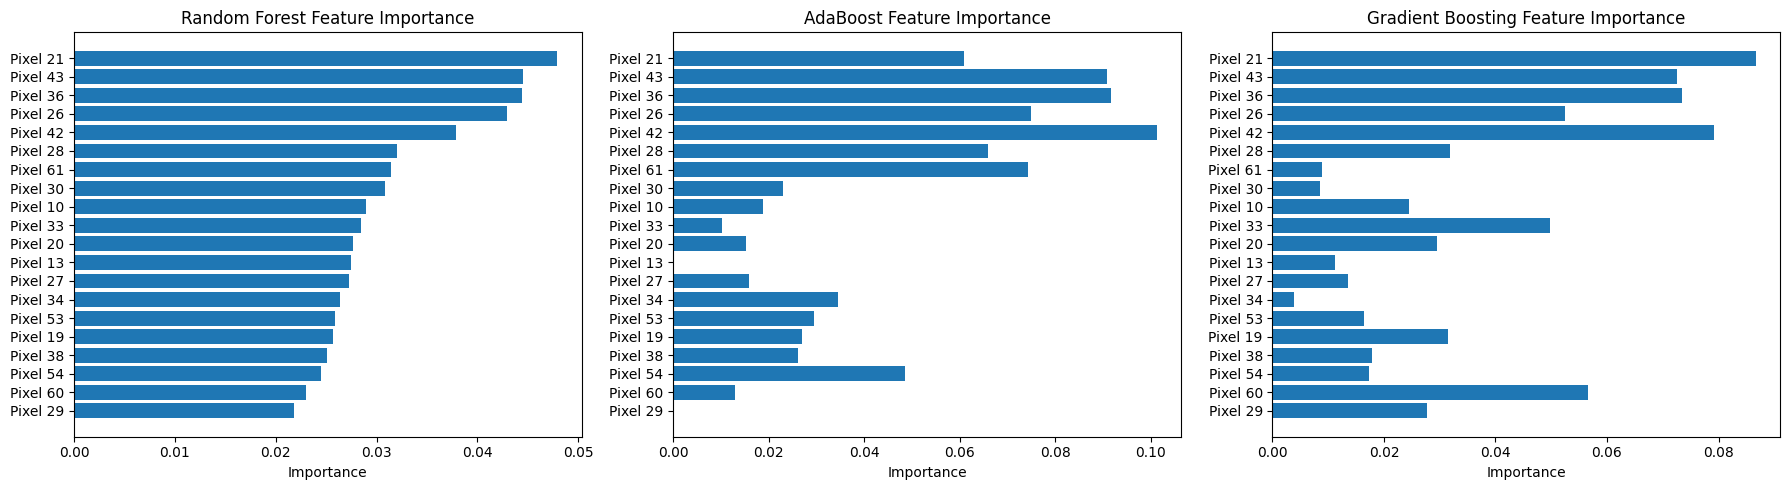

Correlation RF-GB: 0.8102
Correlation RF-AdaBoost: 0.7731
Correlation AdaBoost-GB: 0.7380


In [13]:
# ============= PART G: FEATURE IMPORTANCE COMPARISON ====================
print("\n" + "="*50 + "\nPART G: FEATURE IMPORTANCE COMPARISON\n" + "="*50)

# Get feature importances
rf_importance = rf.feature_importances_
ada_importance = ada.feature_importances_
gb_importance = gb.feature_importances_

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Top 20 features for each
top_n = 20
indices = np.argsort(rf_importance)[-top_n:]

axes[0].barh(range(top_n), rf_importance[indices])
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels([f'Pixel {i}' for i in indices])
axes[0].set_title('Random Forest Feature Importance')
axes[0].set_xlabel('Importance')

axes[1].barh(range(top_n), ada_importance[indices])
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels([f'Pixel {i}' for i in indices])
axes[1].set_title('AdaBoost Feature Importance')
axes[1].set_xlabel('Importance')

axes[2].barh(range(top_n), gb_importance[indices])
axes[2].set_yticks(range(top_n))
axes[2].set_yticklabels([f'Pixel {i}' for i in indices])
axes[2].set_title('Gradient Boosting Feature Importance')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.show()

# Correlation between importances
rf_gb_corr = np.corrcoef(rf_importance, gb_importance)[0,1]
rf_ada_corr = np.corrcoef(rf_importance, ada_importance)[0,1]
ada_gb_corr = np.corrcoef(ada_importance, gb_importance)[0,1]

print(f"Correlation RF-GB: {rf_gb_corr:.4f}")
print(f"Correlation RF-AdaBoost: {rf_ada_corr:.4f}")
print(f"Correlation AdaBoost-GB: {ada_gb_corr:.4f}")

In [14]:
# ============= FINAL COMPARISON TABLE ====================
print("\n" + "="*70 + "\nFINAL COMPARISON TABLE\n" + "="*70)
print(f"{'Method':<25} {'Accuracy':<15} {'Train Time (s)':<15} {'Pred Time (ms)':<15}")
print("-" * 70)
print(f"{'Random Forest':<25} {rf_accuracy:<15.4f} {rf_train_time:<15.3f} {rf_pred_time*1000:<15.2f}")
print(f"{'AdaBoost':<25} {ada_accuracy:<15.4f} {ada_train_time:<15.3f} {ada_pred_time*1000:<15.2f}")
print(f"{'Gradient Boosting':<25} {gb_accuracy:<15.4f} {gb_train_time:<15.3f} {gb_pred_time*1000:<15.2f}")
print(f"{'Stacking':<25} {stacking_accuracy:<15.4f} {stacking_train_time:<15.3f} {stacking_pred_time*1000:<15.2f}")
print(f"{'RF (Tuned)':<25} {rf_tuned_accuracy:<15.4f} {rf_tuned_train_time:<15.3f} {rf_tuned_pred_time*1000:<15.2f}")
print("-" * 70)


FINAL COMPARISON TABLE
Method                    Accuracy        Train Time (s)  Pred Time (ms) 
----------------------------------------------------------------------
Random Forest             0.9722          1.218           27.75          
AdaBoost                  0.8639          1.235           49.53          
Gradient Boosting         0.9750          13.131          9.03           
Stacking                  0.9861          30.823          41.51          
RF (Tuned)                0.9750          0.893           12.55          
----------------------------------------------------------------------
